In [1]:
import pandas as pd

import sklearn as sk
from sklearn import model_selection
from sklearn import ensemble
from sklearn import metrics
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from utiles.functions import PropertyType

## 0. Lectura de datos

In [2]:
df_ent=pd.read_csv("datos/entrenamiento.csv",index_col="id")
df_ap=pd.read_csv("datos/a_predecir.csv",index_col="id")

## 1. Entender los datos (AID)

## 2. Limpiar y transformar los datos (MD)

### Tratamiento Iniciales

In [3]:
Deptos = PropertyType(prop="Departamento",df_ent=df_ent,df_ap=df_ap)
Casas = PropertyType(prop="Casa",df_ent=df_ent,df_ap=df_ap)
Coch = PropertyType(prop="Cochera",df_ent=df_ent,df_ap=df_ap)

Transformacion ARS -> USD exitosa
Filtros iniciales exitosos
Transformacion ARS -> USD exitosa
Filtros iniciales exitosos
Conversion PH -> CASA exitosa
Transformacion ARS -> USD exitosa
Filtros iniciales exitosos


### Tratamiento l3-l4

In [4]:
print("DEPTOS")
Deptos.tratamiento_l3_l4()
print("CASAS")
Casas.tratamiento_l3_l4()
print("COCHERAS")
Coch.tratamiento_l3_l4()

DEPTOS
nan en l3: 4168
nan en l4: 4168
nan en l3 final: 3317
nan en l4 final: 3317
shape antes: (99243, 26)
shape después: (95927, 26)
CASAS
nan en l3: 2088
nan en l4: 2088
nan en l3 final: 1837
nan en l4 final: 1837
shape antes: (18635, 27)
shape después: (16800, 27)
COCHERAS
nan en l3: 42
nan en l4: 42
nan en l3 final: 30
nan en l4 final: 30
shape antes: (2937, 26)
shape después: (2907, 26)


### Tratamiento lat-lon

In [5]:
print("DEPTOS")
Deptos.tratamiento_lat_lon()
print("CASAS")
Casas.tratamiento_lat_lon()
print("COCHERAS")
Coch.tratamiento_lat_lon()

DEPTOS
-34.536262 -34.6857065 -58.3586777 -58.52606201
CASAS
-34.5360918 -34.69185638 -58.371198 -58.5300630656
COCHERAS
-34.5521431 -34.63920212 -58.37121964 -58.5005188


### Tratamiento ambientes

In [6]:
print("DEPTOS")
Deptos.tratamiento_ambientes()
print("CASAS")
Casas.tratamiento_ambientes()
print("COCHERAS")
Coch.tratamiento_ambientes()

DEPTOS
Departamento
rooms_def-----
Max rooms_def_Departamento = 9.0
Pasando a nan 76 rooms_def de Departamento
bedrooms-----
Max bedrooms_Departamento = 11.0
Pasando a nan 9 bedrooms de Departamento
bathrooms-----
Max bathrooms_Departamento = 6.0
Pasando a nan 30 bathrooms de Departamento
CASAS
Casa
rooms_def-----
Max rooms_def_Casa = 16.0
Pasando a nan 21 rooms_def de Casa
bedrooms-----
Max bedrooms_Casa = 12.0
Pasando a nan 24 bedrooms de Casa
bathrooms-----
Max bathrooms_Casa = 8.0
Pasando a nan 11 bathrooms de Casa
COCHERAS


### Tratamiento surface_total vs surface_covered

In [7]:
print("DEPTOS")
Deptos.tratamiento_surface_cov_tot()
print("CASAS")
Casas.tratamiento_surface_cov_tot()
print("COCHERAS")
Coch.tratamiento_surface_cov_tot()

DEPTOS
cantidad cov>tot en ent:552
cantidad cov>tot en ap:17
cantidad cov>tot en ent después de rotacion:0
cantidad cov>tot en ap después de rotacion:0
valores max de deptos en ap de surface_covered a pasar a nan 0
valores min de deptos en ap de surface_covered a pasar a nan 6
Max y min de deptos en ap : max    439.0
min     14.0
Name: surface_covered, dtype: float64

-------------

valores max de deptos en ap de surface_total a pasar a nan 1
valores min de deptos en ap de surface_total a pasar a nan 2
Max y min de deptos en ap : max    605.0
min     14.0
Name: surface_total, dtype: float64
nan en covered antes : 19303
nan en covered despues : 17572
nan en total antes : 20462
nan en total despues : 17572
min cov = 14.0
max cov = 439.0
min tot = 14.0
max tot = 605.0
datos de surface_total a nan: 226
datos de surface_covered a nan: 286
min : 38.659793814432994
Cantidad de valores pasados a nan: 176
CASAS
cantidad cov>tot en ent:271
cantidad cov>tot en ap:10
cantidad cov>tot en ent despué

### Tratamiento outliers price/m2

In [8]:
print("DEPTOS")
Deptos.tratamiento_price_m2()
print("CASAS")
Casas.tratamiento_price_m2()
print("COCHERAS")
Coch.tratamiento_price_m2()

DEPTOS
1 -------------

2 -------------
shape antes de eliminar primeros outlaiers (95927, 36)
shape despues de eliminar primeros outlaiers (95612, 36)

3 -------------

4 -------------
Palermo
vamos a eliminar : 105
Recoleta
vamos a eliminar : 541
Belgrano
vamos a eliminar : 757
Almagro
vamos a eliminar : 627
Caballito
vamos a eliminar : 306
Villa Crespo
vamos a eliminar : 180
Balvanera
vamos a eliminar : 58
Villa Urquiza
vamos a eliminar : 217
Flores
vamos a eliminar : 30
Nuñez
vamos a eliminar : 204
San Nicolás
vamos a eliminar : 82
Colegiales
vamos a eliminar : 62
Monserrat
vamos a eliminar : 59
Puerto Madero
vamos a eliminar : 91
San Cristobal
vamos a eliminar : 10
Villa Devoto
vamos a eliminar : 101
Villa del Parque
vamos a eliminar : 31
San Telmo
vamos a eliminar : 46
Saavedra
vamos a eliminar : 96
Liniers
vamos a eliminar : 7
Boedo
vamos a eliminar : 22
Parque Chacabuco
vamos a eliminar : 20
Villa Luro
vamos a eliminar : 12
Retiro
vamos a eliminar : 42
Floresta
vamos a eliminar

### Tratamiento rooms - surface_covered

In [9]:
print("DEPTOS")
Deptos.tratamiento_rooms_surfaceCovered()
print("CASAS")
Casas.tratamiento_rooms_surfaceCovered()
print("COCHERAS")
Coch.tratamiento_rooms_surfaceCovered()

DEPTOS
nan surface_covered antes : 18034
***    ***    ***   ***   ***   ***   ***
3.0
El valor medio de cada room es : 70.68369506373345
***    ***    ***   ***   ***   ***   ***
2.0
El valor medio de cada room es : 45.90512901909211
***    ***    ***   ***   ***   ***   ***
4.0
El valor medio de cada room es : 112.64685526429622
***    ***    ***   ***   ***   ***   ***
1.0
El valor medio de cada room es : 34.8411468178954
***    ***    ***   ***   ***   ***   ***
5.0
El valor medio de cada room es : 173.3486739469579
***    ***    ***   ***   ***   ***   ***
6.0
El valor medio de cada room es : 230.19946091644204
***    ***    ***   ***   ***   ***   ***
8.0
El valor medio de cada room es : 264.3606557377049
***    ***    ***   ***   ***   ***   ***
7.0
El valor medio de cada room es : 252.15929203539824
***    ***    ***   ***   ***   ***   ***
9.0
El valor medio de cada room es : 272.3125
***    ***    ***   ***   ***   ***   ***
11.0
El valor medio de cada room es : 208.666666666

### Tratamiento final nan en Surfaces

In [10]:
print("DEPTOS")
Deptos.tratamiento_final_nan_surfaces()
print("CASAS")
Casas.tratamiento_final_nan_surfaces()
print("COCHERAS")
Coch.tratamiento_final_nan_surfaces()

DEPTOS
shape antes de la eliminacion : (85401, 38)
shape despues de la eliminacion : (85260, 38)
nan en total antes : 11646
nan en total despues : 1
CASAS
shape antes de la eliminacion : (14457, 39)
shape despues de la eliminacion : (14356, 39)
nan en total antes : 824
nan en total despues : 0
COCHERAS
shape antes de la eliminacion : (2767, 28)
shape despues de la eliminacion : (1394, 28)
nan en total antes : 14
nan en total despues : 0


### Tratamiento final nan ambientes

In [11]:
print("DEPTOS")
Deptos.tratamiento_final_nan_ambientes()
print("CASAS")
Casas.tratamiento_final_nan_ambientes()
print("COCHERAS")
Coch.tratamiento_final_nan_ambientes()

DEPTOS
nan en rooms_rec ANTES:1
nan en bedrooms_rec ANTES:97
nan en bathrooms_rec ANTES:97
nan en rooms_rec DESPUES:1
nan en bedrooms_rec DESPUES:1
nan en bathrooms_rec DESPUES:1
nan en rooms_rec ULTIMO :0
nan en bedrooms_rec ULTIMO:0
nan en bathrooms_rec ULTIMO:0
CASAS
nan en rooms_rec ANTES:0
nan en bedrooms_rec ANTES:66
nan en bathrooms_rec ANTES:66
nan en rooms_rec DESPUES:0
nan en bedrooms_rec DESPUES:0
nan en bathrooms_rec DESPUES:0
nan en rooms_rec ULTIMO :0
nan en bedrooms_rec ULTIMO:0
nan en bathrooms_rec ULTIMO:0
COCHERAS


### Tratamiento final nan pm2

In [12]:
print("DEPTOS")
Deptos.tratamiento_final_nan_pm2()
print("CASAS")
Casas.tratamiento_final_nan_pm2()
print("COCHERAS")
Coch.tratamiento_final_nan_pm2()

DEPTOS
1 -------------

2 -------------
shape antes de eliminar primeros outlaiers (85260, 38)
shape despues de eliminar primeros outlaiers (85260, 38)

3 -------------

4 -------------
Palermo
vamos a eliminar : 0
Recoleta
vamos a eliminar : 0
Almagro
vamos a eliminar : 0
Belgrano
vamos a eliminar : 0
Caballito
vamos a eliminar : 0
Villa Crespo
vamos a eliminar : 0
Balvanera
vamos a eliminar : 0
Villa Urquiza
vamos a eliminar : 0
Flores
vamos a eliminar : 0
Colegiales
vamos a eliminar : 0
Nuñez
vamos a eliminar : 0
Monserrat
vamos a eliminar : 0
San Nicolás
vamos a eliminar : 0
Puerto Madero
vamos a eliminar : 0
San Cristobal
vamos a eliminar : 0
Villa del Parque
vamos a eliminar : 0
San Telmo
vamos a eliminar : 0
Villa Devoto
vamos a eliminar : 0
Liniers
vamos a eliminar : 0
Saavedra
vamos a eliminar : 0
Boedo
vamos a eliminar : 0
Parque Chacabuco
vamos a eliminar : 0
Villa Luro
vamos a eliminar : 0
Floresta
vamos a eliminar : 0
Retiro
vamos a eliminar : 0
Barracas
vamos a eliminar :

### Tratamiendo final nan resto

In [13]:
print("DEPTOS")
Deptos.tratamiento_ultimos_nan()
print("CASAS")
Casas.tratamiento_ultimos_nan()
print("COCHERAS")
Coch.tratamiento_ultimos_nan()

DEPTOS
nan surface_covered antes : 1
***    ***    ***   ***   ***   ***   ***
3.0
El valor medio de cada room es : 86.10083257765456
***    ***    ***   ***   ***   ***   ***
2.0
El valor medio de cada room es : 53.6382279725297
***    ***    ***   ***   ***   ***   ***
4.0
El valor medio de cada room es : 128.79361596615598
***    ***    ***   ***   ***   ***   ***
1.0
El valor medio de cada room es : 34.86473708614745
***    ***    ***   ***   ***   ***   ***
5.0
El valor medio de cada room es : 199.377003368423
***    ***    ***   ***   ***   ***   ***
6.0
El valor medio de cada room es : 273.4924853430103
***    ***    ***   ***   ***   ***   ***
8.0
El valor medio de cada room es : 547.0796903460838
***    ***    ***   ***   ***   ***   ***
7.0
El valor medio de cada room es : 297.6128983250408
***    ***    ***   ***   ***   ***   ***
9.0
El valor medio de cada room es : 514.3680555555555
***    ***    ***   ***   ***   ***   ***
11.0
El valor medio de cada room es : 208.6666666

### Feature cov_total_def

In [14]:
print("ya estuvo, segui!")

ya estuvo, segui!


In [15]:
print("DEPTOS")
Deptos.feature_cov_total_def()
print("CASAS")
Casas.feature_cov_total_def()
print("COCHERAS")
Coch.feature_cov_total_def()

DEPTOS
CASAS
COCHERAS


### Key-words

In [16]:
print("DEPTOS")
Deptos.key_words()
print("CASAS")
Casas.key_words()
print("COCHERAS")
Coch.key_words()

DEPTOS
CASAS
COCHERAS


In [17]:
Deptos.df.columns

Index(['ad_type', 'start_date', 'end_date', 'created_on', 'lat', 'lon', 'l1',
       'l2', 'l3', 'l4', 'l5', 'l6', 'rooms', 'bedrooms', 'bathrooms',
       'surface_total', 'surface_covered', 'currency', 'price_period', 'title',
       'description', 'property_type', 'operation_type', 'price', 'l4_title',
       'l4_descr', 'dataset', 'rooms_title', 'rooms_description',
       'categorize_rooms', 'rooms_def', 'rooms_rec', 'bedrooms_rec',
       'bathrooms_rec', 'cov_total', 'price_m2_real',
       'price_m2_x_surface_total', 'price_m2', 'cov_total_def', 'PH',
       'tiene_pileta', 'a_estrenar', 'de_pozo', 'Palermo_Chico', 'Palermo'],
      dtype='object')

In [18]:
Casas.df.columns

Index(['ad_type', 'start_date', 'end_date', 'created_on', 'lat', 'lon', 'l1',
       'l2', 'l3', 'l4', 'l5', 'l6', 'rooms', 'bedrooms', 'bathrooms',
       'surface_total', 'surface_covered', 'currency', 'price_period', 'title',
       'description', 'property_type', 'operation_type', 'price', 'ph',
       'l4_title', 'l4_descr', 'dataset', 'rooms_title', 'rooms_description',
       'categorize_rooms', 'rooms_def', 'rooms_rec', 'bedrooms_rec',
       'bathrooms_rec', 'cov_total', 'price_m2_real',
       'price_m2_x_surface_total', 'price_m2', 'cov_total_def', 'PH',
       'tiene_pileta', 'a_estrenar', 'de_pozo', 'Palermo_Chico', 'Palermo'],
      dtype='object')

In [19]:
Coch.df.columns

Index(['ad_type', 'start_date', 'end_date', 'created_on', 'lat', 'lon', 'l1',
       'l2', 'l3', 'l4', 'l5', 'l6', 'surface_total', 'surface_covered',
       'currency', 'price_period', 'title', 'description', 'property_type',
       'operation_type', 'price', 'l4_title', 'l4_descr', 'dataset',
       'cov_total', 'price_m2_real', 'price_m2_x_surface_total', 'price_m2',
       'cov_total_def', 'a_estrenar', 'de_pozo', 'Palermo_Chico', 'Palermo'],
      dtype='object')

In [20]:
print("segui")

segui


In [21]:
print("DEPTOS")
Deptos.eliminacion_columnas()
print("CASAS")
Casas.eliminacion_columnas()
print("COCHERAS")
Coch.eliminacion_columnas()

DEPTOS
CASAS
COCHERAS


In [22]:
Coch.df.columns

Index(['lat', 'lon', 'l3', 'l4', 'surface_total', 'surface_covered', 'title',
       'description', 'property_type', 'price', 'price_m2_x_surface_total',
       'cov_total_def', 'a_estrenar', 'de_pozo', 'Palermo_Chico', 'Palermo'],
      dtype='object')

<Axes: ylabel='id'>

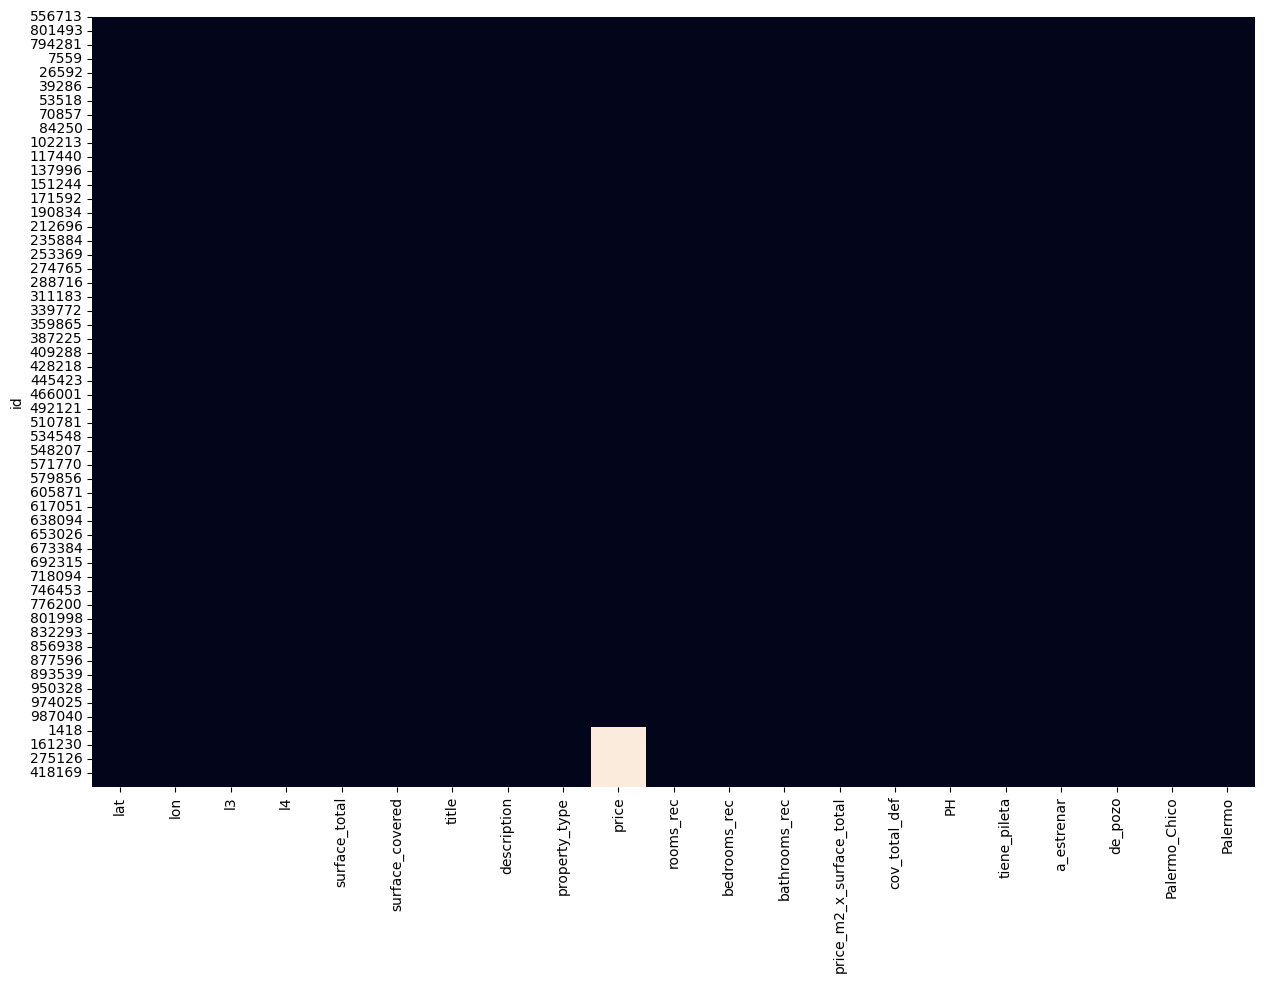

In [23]:
import seaborn as sns
plt.figure(figsize=(15,10))
sns.heatmap(Deptos.df.isnull(), cbar=False)

<Axes: ylabel='id'>

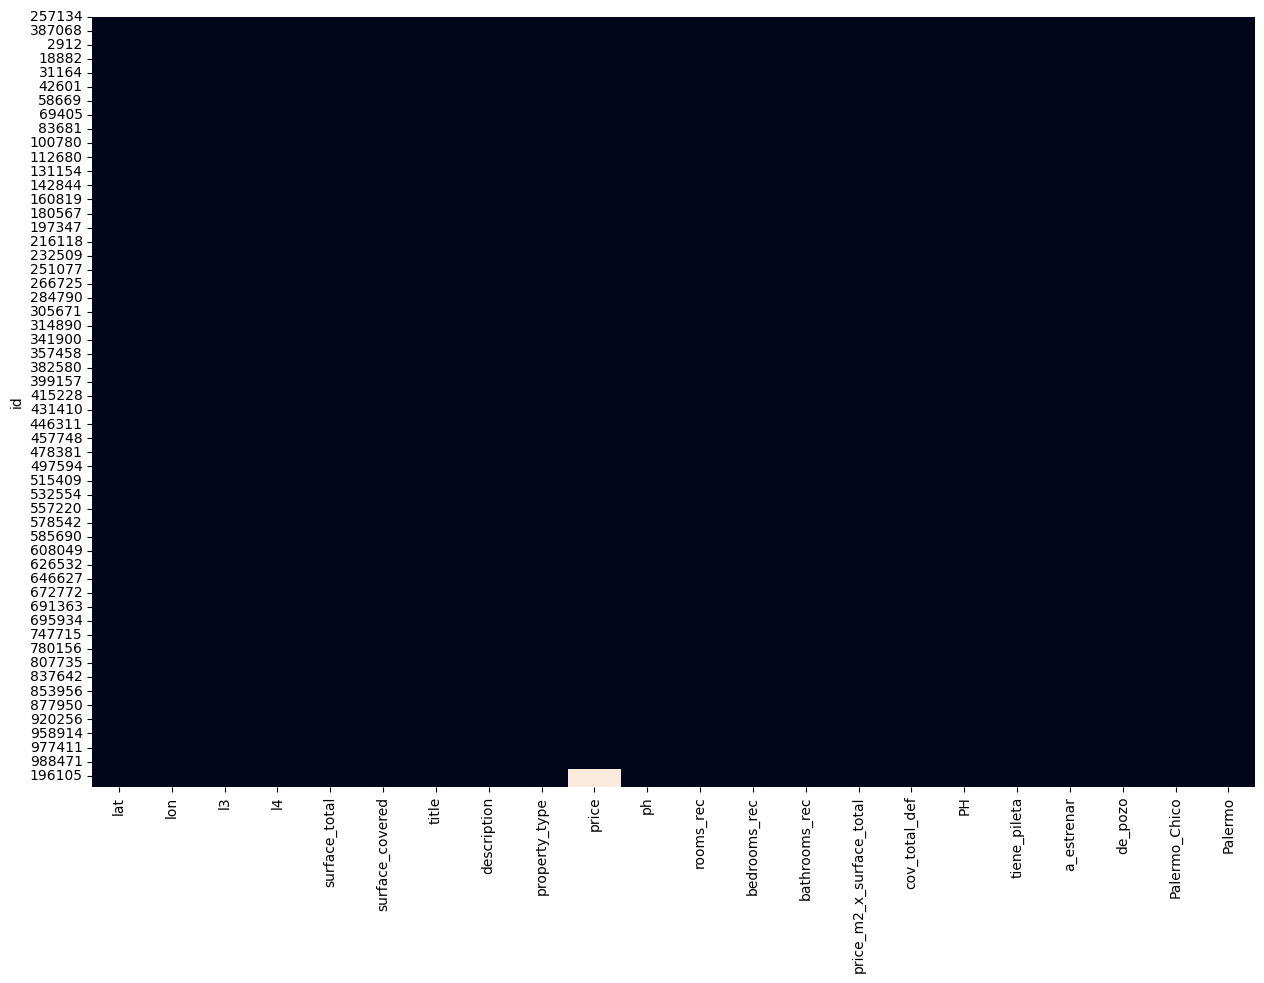

In [24]:
import seaborn as sns
plt.figure(figsize=(15,10))
sns.heatmap(Casas.df.isnull(), cbar=False)

<Axes: ylabel='id'>

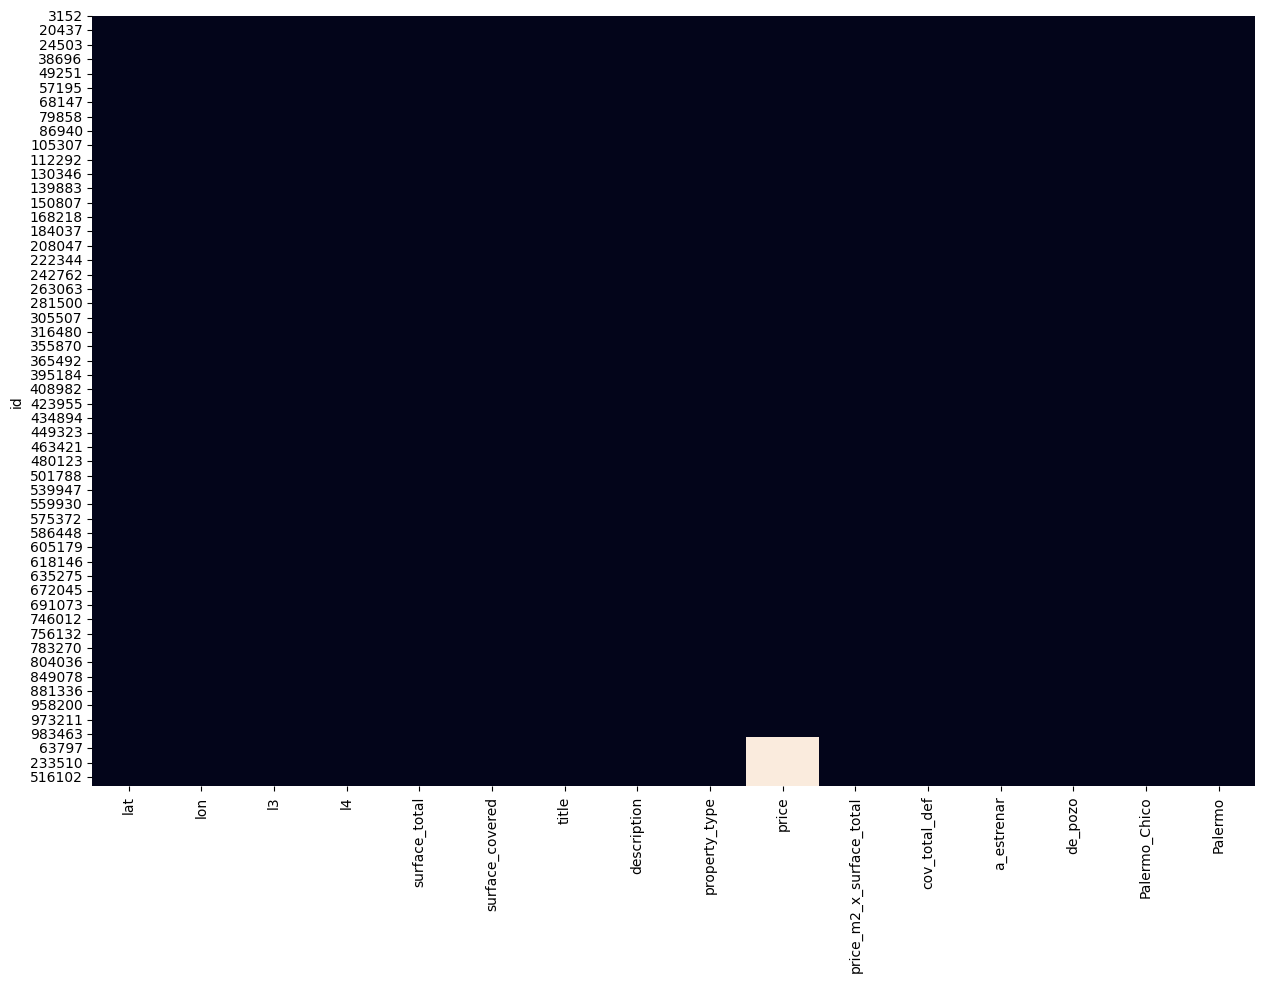

In [25]:
import seaborn as sns
plt.figure(figsize=(15,10))
sns.heatmap(Coch.df.isnull(), cbar=False)

## 3. Entrenamiento del modelos (AA)

### Tests de hiperparametros

In [38]:
Deptos.model_entrenamiento(modo="version_train_test_split_iterativo")

shape df_ent: (78664, 21)
df_ent columns: Index(['lat', 'lon', 'surface_total', 'surface_covered', 'price', 'rooms_rec',
       'bedrooms_rec', 'bathrooms_rec', 'price_m2_x_surface_total',
       'cov_total_def', 'PH', 'tiene_pileta', 'a_estrenar', 'de_pozo',
       'Palermo_Chico', 'Palermo'],
      dtype='object')
version_train_test_split_iterativo
n_estimators=10 -- max_depth=5 --> score_train=93869.49 - score_test=101990.00 - best_score_test=101990.00
n_estimators=10 -- max_depth=10 --> score_train=55869.54 - score_test=70643.24 - best_score_test=70643.24
n_estimators=10 -- max_depth=20 --> score_train=29679.54 - score_test=71250.10 - best_score_test=70643.24
n_estimators=10 -- max_depth=30 --> score_train=28240.21 - score_test=66095.19 - best_score_test=66095.19
n_estimators=10 -- max_depth=50 --> score_train=28496.59 - score_test=68282.19 - best_score_test=66095.19
n_estimators=10 -- max_depth=None --> score_train=28496.59 - score_test=68282.19 - best_score_test=66095.19
n_estima

KeyboardInterrupt: 

In [39]:
Casas.model_entrenamiento(modo="version_train_test_split_iterativo")

shape df_ent: (14029, 22)
df_ent columns: Index(['lat', 'lon', 'surface_total', 'surface_covered', 'price', 'ph',
       'rooms_rec', 'bedrooms_rec', 'bathrooms_rec',
       'price_m2_x_surface_total', 'cov_total_def', 'PH', 'tiene_pileta',
       'a_estrenar', 'de_pozo', 'Palermo_Chico', 'Palermo'],
      dtype='object')
version_train_test_split_iterativo
n_estimators=10 -- max_depth=5 --> score_train=122496.92 - score_test=141042.74 - best_score_test=141042.74
n_estimators=10 -- max_depth=10 --> score_train=72377.95 - score_test=122021.05 - best_score_test=122021.05
n_estimators=10 -- max_depth=20 --> score_train=48949.31 - score_test=120841.01 - best_score_test=120841.01
n_estimators=10 -- max_depth=30 --> score_train=50926.44 - score_test=128683.25 - best_score_test=120841.01
n_estimators=10 -- max_depth=50 --> score_train=51088.86 - score_test=121519.71 - best_score_test=120841.01
n_estimators=10 -- max_depth=None --> score_train=51088.86 - score_test=121519.71 - best_score_test=1

In [40]:
Coch.model_entrenamiento(modo="version_train_test_split_iterativo")

shape df_ent: (1305, 16)
df_ent columns: Index(['lat', 'lon', 'surface_total', 'surface_covered', 'price',
       'price_m2_x_surface_total', 'cov_total_def', 'a_estrenar', 'de_pozo',
       'Palermo_Chico', 'Palermo'],
      dtype='object')
version_train_test_split_iterativo
n_estimators=10 -- max_depth=5 --> score_train=5821.93 - score_test=6527.07 - best_score_test=6527.07
n_estimators=10 -- max_depth=10 --> score_train=4261.35 - score_test=6757.47 - best_score_test=6527.07
n_estimators=10 -- max_depth=20 --> score_train=3323.87 - score_test=6159.64 - best_score_test=6159.64
n_estimators=10 -- max_depth=30 --> score_train=3350.90 - score_test=6113.49 - best_score_test=6113.49
n_estimators=10 -- max_depth=50 --> score_train=3349.05 - score_test=6114.04 - best_score_test=6113.49
n_estimators=10 -- max_depth=None --> score_train=3349.05 - score_test=6114.04 - best_score_test=6113.49
n_estimators=50 -- max_depth=5 --> score_train=5667.38 - score_test=7039.67 - best_score_test=6113.49
n_

### Version final con hiperparametros elegidos

In [41]:
print("DEPTOS")
print("")
Deptos.model_entrenamiento(modo="version_entrenamiento_final",n_estimators=50,max_depth=50)
Deptos.model_prediccion()
print("CASAS")
print("")
Casas.model_entrenamiento(modo="version_entrenamiento_final",n_estimators=100,max_depth=20)
Casas.model_prediccion()

print("COCHERAS")
print("")
Coch.model_entrenamiento(modo="version_entrenamiento_final",n_estimators=10,max_depth=30)
Coch.model_prediccion()

DEPTOS

shape df_ent: (78664, 21)
df_ent columns: Index(['lat', 'lon', 'surface_total', 'surface_covered', 'price', 'rooms_rec',
       'bedrooms_rec', 'bathrooms_rec', 'price_m2_x_surface_total',
       'cov_total_def', 'PH', 'tiene_pileta', 'a_estrenar', 'de_pozo',
       'Palermo_Chico', 'Palermo'],
      dtype='object')
version_entrenamiento_final
Modelo finalizado listo para la prediccion
shape df_ap: (6596, 21)
df_ap columns: Index(['lat', 'lon', 'surface_total', 'surface_covered', 'price', 'rooms_rec',
       'bedrooms_rec', 'bathrooms_rec', 'price_m2_x_surface_total',
       'cov_total_def', 'PH', 'tiene_pileta', 'a_estrenar', 'de_pozo',
       'Palermo_Chico', 'Palermo'],
      dtype='object')
Predicciones realizadas
CASAS

shape df_ent: (14029, 22)
df_ent columns: Index(['lat', 'lon', 'surface_total', 'surface_covered', 'price', 'ph',
       'rooms_rec', 'bedrooms_rec', 'bathrooms_rec',
       'price_m2_x_surface_total', 'cov_total_def', 'PH', 'tiene_pileta',
       'a_estren

In [42]:
df_ap_concat = pd.concat([Deptos.df_ap[["price"]] , Casas.df_ap[["price"]] , Coch.df_ap[["price"]]], axis=0)

In [43]:
df_ap_concat["price"].to_csv("solucion_v3b_hp.csv")

### Evaluacion

In [36]:
# Deptos
X = Deptos.df_ent[Deptos.df_ent.columns.drop('price')]
importances=pd.DataFrame({"importance": Deptos.reg.feature_importances_}, index=X.columns).sort_values(by="importance", ascending=False)
importances

,importance
price_m2_x_surface_total,0.769934
surface_covered,0.056640
cov_total_def,0.038437
lat,0.035592
lon,0.033316
surface_total,0.025919
tiene_pileta,0.013158
bathrooms_rec,0.007571
Palermo_Chico,0.005477
rooms_rec,0.003852


<Axes: xlabel='importance', ylabel='None'>

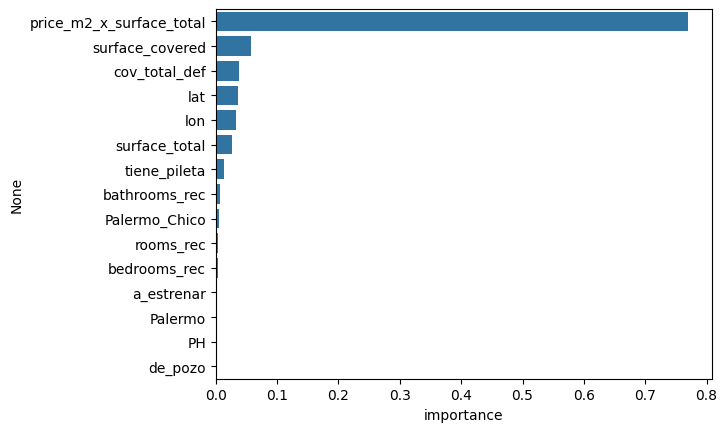

In [37]:
sns.barplot(data=importances,x="importance",y=importances.index)